In [1]:
from util import *
from simulator import QuantumCircuitSimulator
from converter import CircuitConverter
from zne import ZNESimulator
from generator import QuantumGenerator
from extractor import QuantumGraphExtractor

Using CPU for statevector simulation

Ideal Expectation Values (Iteration 1): [-0.38190916383163814, 1.0000000000000004, -1.1102230246251565e-16, 2.220446049250313e-16, 0.5000000000000006]
Noisy Expectation Values (Iteration 1): [-0.1962890625, 0.7021484375, -0.01953125, 0.04833984375, 0.373291015625]


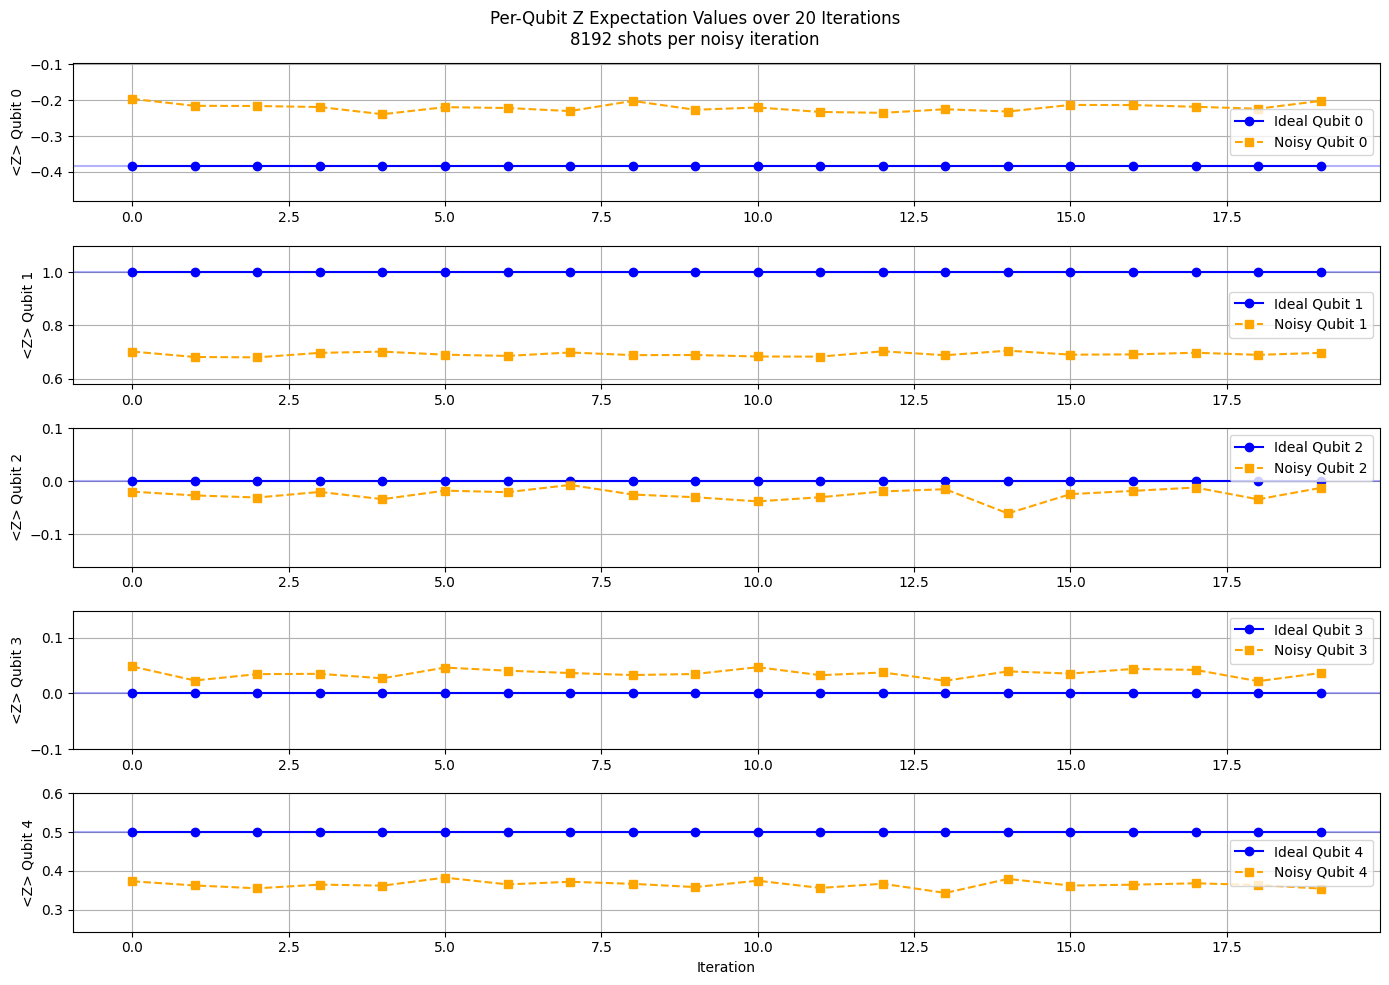

In [2]:
n_qubits = 5
depth = 6
circuit = random_circuit(n_qubits, depth, measure=False, seed=42)

# Initialize the simulator with the given circuit and parameters
simulator = QuantumCircuitSimulator(circuit, n_qubits, shots=8192, iterations=20, use_ibm=False)

# Run the simulation to obtain compiled circuits and expectation values
ideal_circuit, noisy_circuit, ideal_expectation, noisy_expectation = simulator.run_simulation()

# Display results from the first iteration for demonstration
print("\nIdeal Expectation Values (Iteration 1):", ideal_expectation[0])
print("Noisy Expectation Values (Iteration 1):", noisy_expectation[0])

# Plot the per-qubit expectation values over iterations
simulator.plot_expectations(np.array(ideal_expectation), np.array(noisy_expectation))

In [3]:
# Generate a random circuit (without measurements)
n_qubits = 5
depth = 4
circuit = random_circuit(n_qubits, depth, measure=False, seed=42)

# Create a converter with settings for both graph and frequency conversions.
converter = CircuitConverter(
    max_gate_attributes=3,
    bin_min=-3.14,
    bin_max=3.14,
    bin_size=0.5,
    mode='bin'  # Try 'bin_gate' or 'bin_gate_attr' as alternatives.
)

# Convert to graph representation.
dataset_graph = converter.convert(circuit, conversion_type="graph")
print("Converted dataset (graph representation):")
print(dataset_graph)

# Convert to frequency representation.
dataset_freq = converter.convert(circuit, conversion_type="freq")
print("\nConverted dataset (frequency representation):")
print(dataset_freq)

# Convert to CNN representation.
dataset_cnn = converter.convert(circuit, conversion_type="cnn")
print("\nConverted dataset (cnn representation):")
print(dataset_cnn)

Converted dataset (graph representation):
{'nodes': [{'id': 0, 'vector': ['in', 0, 0, 0, 0, 0]}, {'id': 1, 'vector': ['in', 0, 0, 0, 0, 0]}, {'id': 2, 'vector': ['in', 0, 0, 0, 0, 0]}, {'id': 3, 'vector': ['in', 0, 0, 0, 0, 0]}, {'id': 4, 'vector': ['h', 0, 0, 0, 0, 0]}, {'id': 5, 'vector': ['in', 0, 0, 0, 0, 0]}, {'id': 6, 'vector': ['c3sx', 1, 0, 0, 0, 0]}, {'id': 7, 'vector': ['c3sx', 0, 1, 0, 0, 0]}, {'id': 8, 'vector': ['c3sx', 0, 1, 0, 0, 0]}, {'id': 9, 'vector': ['c3sx', 0, 1, 0, 0, 0]}, {'id': 10, 'vector': ['ccz', 1, 0, 0, 0, 0]}, {'id': 11, 'vector': ['ccz', 0, 1, 0, 0, 0]}, {'id': 12, 'vector': ['ccz', 0, 1, 0, 0, 0]}, {'id': 13, 'vector': ['cu1', 1, 0, 5.200160019627613, 0, 0]}, {'id': 14, 'vector': ['cu1', 0, 1, 5.200160019627613, 0, 0]}, {'id': 15, 'vector': ['rccx', 1, 0, 0, 0, 0]}, {'id': 16, 'vector': ['rccx', 0, 1, 0, 0, 0]}, {'id': 17, 'vector': ['rccx', 0, 1, 0, 0, 0]}, {'id': 18, 'vector': ['ch', 1, 0, 0, 0, 0]}, {'id': 19, 'vector': ['ch', 0, 1, 0, 0, 0]}, {'id': 

Ideal Expectation Values: [-0.38190916383163814, 1.0000000000000004, -1.1102230246251565e-16, 2.220446049250313e-16, 0.5000000000000006]
Noisy Expectation Values: [-0.093994140625, 0.12353515625, 0.0087890625, -0.000732421875, 0.134033203125]
ZNE Mitigated Values (linear_zne): [-0.16495768229166669, 0.19091796875000003, -0.017822265624999993, 0.0006510416666666696, 0.15755208333333334]
ZNE Mitigated Values (richardson_zne): [-0.2941894531250002, 0.43725585937500033, 0.03857421875000008, -0.006103515625000103, 0.21777343750000014]


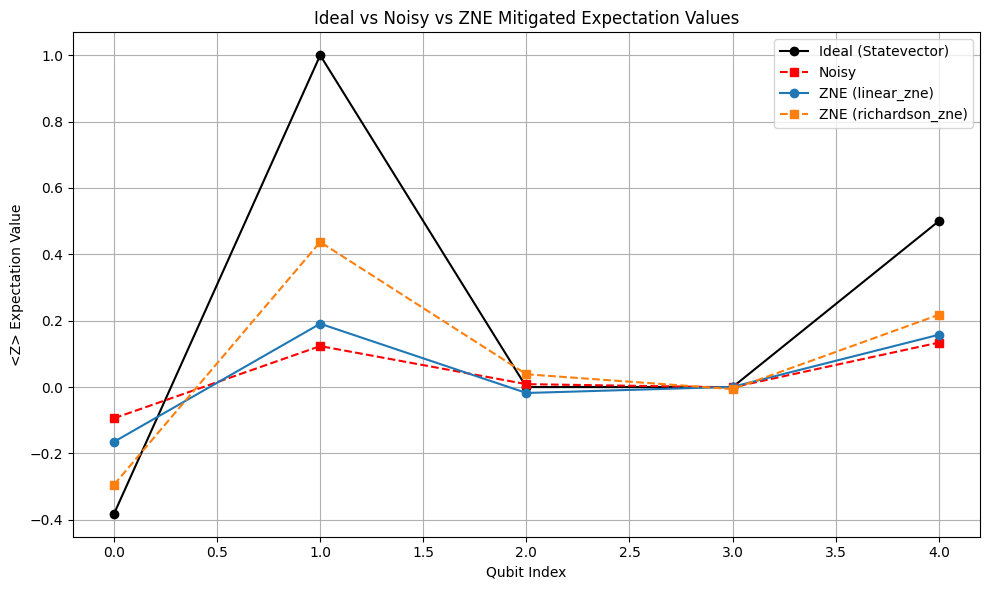

In [4]:
# Generate a random circuit (without measurements).
n_qubits = 5
depth = 6
shots = 8192
scale_factors = [1.0, 2.0, 3.0]
circuit = random_circuit(n_qubits, depth, measure=False, seed=42)

# Initialize the ZNESimulator.
zne_simulator = ZNESimulator(
    circuit=circuit,
    n_qubits=n_qubits,
    shots=shots,
    scale_factors=scale_factors
)

# Run the simulation.
ideal_exps, noisy_exps, zne_results = zne_simulator.run_simulation(return_ieal=True, return_noisy=True)

# Print the results.
print("Ideal Expectation Values:", ideal_exps)
print("Noisy Expectation Values:", noisy_exps)
for method, vals in zne_results.items():
    print(f"ZNE Mitigated Values ({method}):", vals)

# Plot the results.
zne_simulator.plot_results(ideal_exps, noisy_exps, zne_results)

In [ ]:
# Create an instance of QuantumGenerator with desired parameters.
qgen = QuantumGenerator(
    n_qubits=4,
    depth=(4, 5, 2),         # Depth values: 4, 6, 8
    circuits_per_depth=1000,
    shots=8192,
    scale_factors=[1.0, 2.0, 3.0],
    observable_mode="rand",   # Use random observables ("X", "Y", or "Z")
    fixed_pauli=None,         # If fixed mode is used, provide a string e.g. "XYZZZ"
    optimization_level=0,
    transpile_backend=None,   # Uses default GenericBackendV2 if not provided.
    conversion_type=["cnn", "graph", "freq"],  # List of conversions, options: 'graph', 'freq', 'cnn' etc.
    save=True,
    filename="../../data/raw_data" # Additional info like nqbit, depth_params, circuits_per_depth are appended to file-name
)

# Generate the data and store it in a DataFrame.
df = qgen.generate_data(output_format='csv')
print("Generated Data:")
print(df)


Generating circuits at depth: 4


Circuits at depth 4:   0%|          | 0/1000 [00:00<?, ?it/s]

Using CPU for statevector simulation


Circuits at depth 4:   0%|          | 1/1000 [00:03<1:02:30,  3.75s/it]

Using CPU for statevector simulation


...

Using CPU for statevector simulation


Circuits at depth 4:  12%|█▏        | 116/1000 [08:17<1:04:56,  4.41s/it]

Using CPU for statevector simulation


Circuits at depth 4:  12%|█▏        | 117/1000 [08:21<1:04:45,  4.40s/it]

Using CPU for statevector simulation


In [ ]:
backend = qgen.transpile_backend  # Replace with actual backend if available.
extractor = QuantumGraphExtractor(filepath='../../data/raw_data_graph_4_(4, 5, 2)_4.csv', n_qubits=5, backend=backend, data_type="graph")
extractor.process()
data_objects = extractor.get_data()
if data_objects is not None:
    print("Data processing complete.")
extractor.export_data("../../data/processed_data_graph_4_(4, 5, 2)_4", output_format="csv")

Data processing complete.
Exported processed data to ../../data/processed_data_cnn.csv
